In [30]:
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.datasource import YahooDataSource
from src.prediction import PredictionModeling
from src.bayesianopt import bayesianOpt
from src.gridsearchopt import gridsearchOpt
from src.riskmeasure import CumulativeReturn, ExponationalUtility, MeanSemiDeviation, TotalSemiDeviation
from src.utils import buy_signal_plots, calculate_drawdown
from src.utils import find_cointegrated_pairs,get_top_k_pairs,get_cointergrated_coeff
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Data Extraction

In [2]:
# Extract the Data from the Yahoo Data Source
start_date = datetime.datetime(2018, 3, 29)
end_date = datetime.datetime(2024, 3, 29)
tickers  =  ['SPY','AAPL','ADBE','EBAY','MSFT','QCOM',
                 'HPQ','JNPR','AMD','IBM','DAL','KO']
columns =   ["High","Close","Low","Volume"]
ds = YahooDataSource(start_date,end_date,tickers,columns)

In [3]:
# Get only Close column data
df_pair_search = ds.get_data_by_column_tickers(columns=["Close"],tickers=-1)

In [4]:
df_pair_search

,HPQ_Close,JNPR_Close,AMD_Close,QCOM_Close,SPY_Close,IBM_Close,AAPL_Close,KO_Close,MSFT_Close,DAL_Close,EBAY_Close,ADBE_Close
0,17.298027,19.788225,10.050000,45.878700,234.515732,105.044106,39.491154,34.650608,84.495491,50.740219,36.051117,216.080002
1,16.682497,19.576761,9.530000,44.553925,229.453842,102.743706,39.232235,34.044243,81.949593,48.092583,35.262718,212.279999
2,16.824543,19.601158,9.550000,45.357082,232.394714,102.593102,39.634727,34.610722,83.051277,49.731159,35.486702,215.929993
3,16.998159,19.641829,9.770000,45.530945,234.881088,105.516495,40.392643,35.296871,85.476822,49.860767,35.647961,225.050003
4,17.006044,19.804485,10.020000,45.572361,236.734818,105.454895,40.672741,35.424519,85.523109,50.184772,35.862976,223.539993
...,...,...,...,...,...,...,...,...,...,...,...,...
1505,28.706631,35.946815,179.649994,165.762863,513.142700,182.178711,171.051651,58.318718,424.014771,44.811905,50.280102,499.519989
1506,28.544230,35.966217,178.630005,163.248642,511.724915,180.221741,169.631851,58.231953,418.199554,44.644802,50.094311,507.230011
1507,28.649311,35.937115,177.869995,162.810120,510.779785,179.944931,168.500000,58.366928,417.002899,45.146099,49.947643,507.600006
1508,28.773502,36.169968,179.589996,164.817581,515.072327,182.140533,172.074310,58.839336,416.785339,46.502548,50.769020,504.399994


In [5]:
df_pair_search.head(n=5)
scores, pvalues, pairs = find_cointegrated_pairs(df_pair_search)

top_pairs = get_top_k_pairs(pairs,5)
print("Top pairs",top_pairs)

# Get first pair
tickers = ds.get_tickers(top_pairs[0][0])
print("Top ticker",tickers)

Top pairs [(('AMD_Close', 'MSFT_Close'), 0.006083915736939566)]
Top ticker ['AMD', 'MSFT']


In [6]:
first_series = 'MSFT_Close'
second_series =  'AMD_Close'

In [7]:
# Gather High, Low ,Close , Volume of selected stocks
columns = ["High","Close","Low","Volume"]
df_raw = ds.get_data_by_column_tickers(columns=columns,tickers=tickers)

In [8]:
df_raw

,MSFT_High,MSFT_Volume,MSFT_Low,MSFT_Close,AMD_High,AMD_Volume,AMD_Low,AMD_Close
0,85.439786,45867500,81.838521,84.495491,10.080000,48681400,9.810000,10.050000
1,84.134422,48515400,81.014565,81.949593,10.140000,64824600,9.510000,9.530000
2,83.366044,37213800,81.366367,83.051277,9.770000,54891600,9.300000,9.550000
3,85.874905,35560000,81.218258,85.476822,9.810000,67356900,9.040000,9.770000
4,86.161897,29771900,84.615854,85.523109,10.200000,65758800,9.910000,10.020000
...,...,...,...,...,...,...,...,...
1505,425.122422,17648500,421.374214,424.014771,180.759995,57899100,175.050003,179.649994
1506,422.699426,18060500,416.963331,418.199554,182.800003,71935300,172.000000,178.630005
1507,421.295063,16725600,416.706218,417.002899,182.600006,65322400,176.330002,177.869995
1508,419.772075,16705000,414.392027,416.785339,181.229996,55685600,175.399994,179.589996


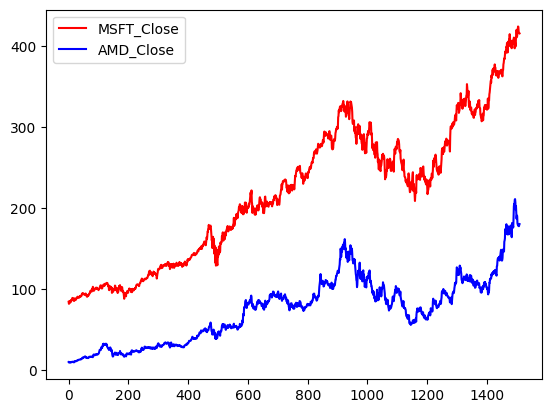

In [9]:
plt.plot(df_raw[first_series],color='r')
plt.plot(df_raw[second_series],color='b')
plt.legend([f'{first_series}',f'{second_series}'])

In [10]:
# Find ratio between co-integrated pairs
coeff = get_cointergrated_coeff(df_raw[first_series],df_raw[second_series])
print(coeff)

-2.024983435795218


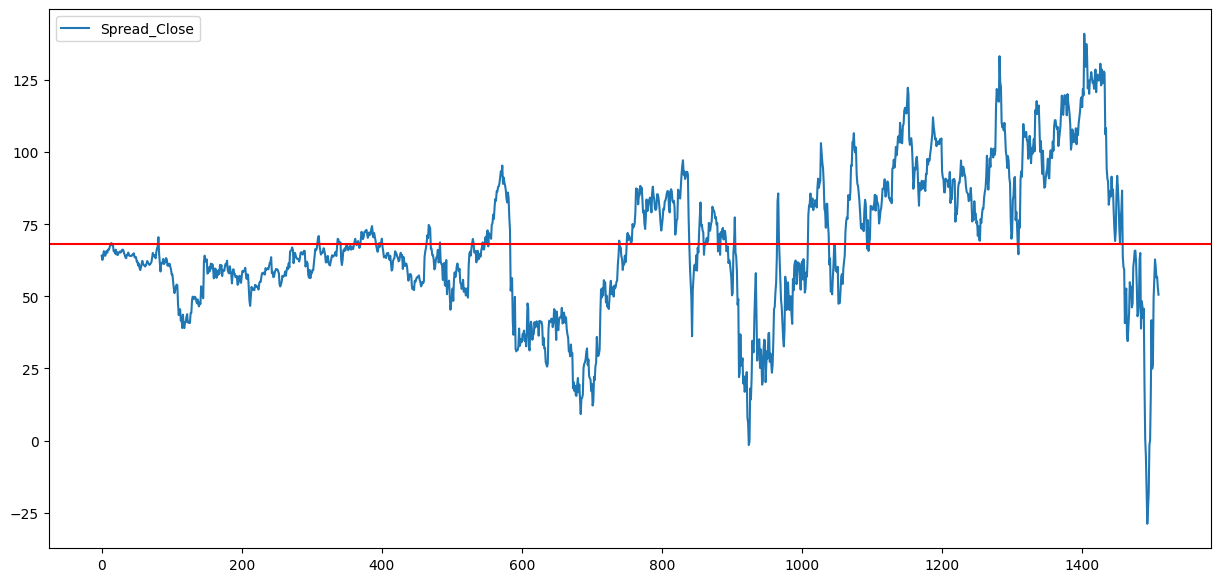

In [11]:
df_raw['Spread_Close'] = df_raw[first_series] + (df_raw[second_series] * coeff)
df_raw['Spread_Close'].plot(figsize=(15,7))
plt.axhline(df_raw['Spread_Close'].mean(),c='red')
plt.legend(['Spread_Close'])

In [12]:
pm = PredictionModeling(df_raw,"Spread_Close",0.60,1)

In [13]:
pm.add_arima_forecast("Spread_Close",order=(1,1,0))

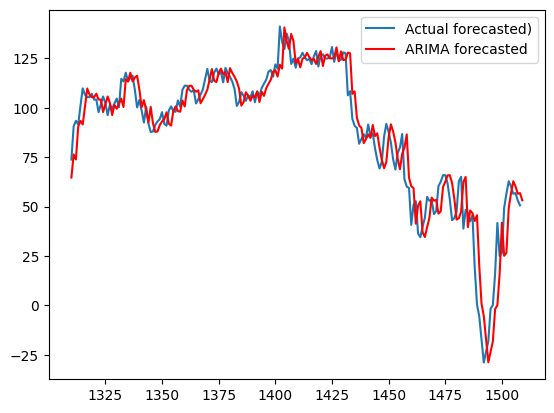

In [16]:
plt.plot(pm.data["Spread_Close_Actual_value_fore_perod_1"][-200:])
plt.plot(pm.data["Spread_Close_ARIMA_forecast_1"][-200:],color='r')
plt.legend(["Actual forecasted)","ARIMA forecasted"])

In [17]:
pm.data

,MSFT_High,MSFT_Volume,MSFT_Low,MSFT_Close,AMD_High,AMD_Volume,AMD_Low,AMD_Close,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,85.439786,45867500,81.838521,84.495491,10.080000,48681400,9.810000,10.050000,64.144407,[62.65150098793252],62.651501,62.651501,NaN,NaN
1,84.134422,48515400,81.014565,81.949593,10.140000,64824600,9.510000,9.530000,62.651501,[63.71268496256526],63.712685,63.712685,NaN,NaN
2,83.366044,37213800,81.366367,83.051277,9.770000,54891600,9.300000,9.550000,63.712685,[65.69273280473092],65.692733,65.692733,NaN,NaN
3,85.874905,35560000,81.218258,85.476822,9.810000,67356900,9.040000,9.770000,65.692733,[65.23277448240322],65.232774,65.232774,NaN,NaN
4,86.161897,29771900,84.615854,85.523109,10.200000,65758800,9.910000,10.020000,65.232774,[64.07259420340272],64.072594,64.072594,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,425.122422,17648500,421.374214,424.014771,180.759995,57899100,175.050003,179.649994,60.226509,[56.47675341964515],56.476753,56.476753,62.798994,[62.798994486580305]
1506,422.699426,18060500,416.963331,418.199554,182.800003,71935300,172.000000,178.630005,56.476753,[56.8191053326409],56.819105,56.819105,60.233856,[60.233855661587235]
1507,421.295063,16725600,416.706218,417.002899,182.600006,65322400,176.330002,177.869995,56.819105,[53.11857153671639],53.118572,53.118572,56.486341,[56.48634078437904]
1508,419.772075,16705000,414.392027,416.785339,181.229996,55685600,175.399994,179.589996,53.118572,[50.59388895014553],50.593889,50.593889,56.818218,[56.81821758299125]


In [18]:
pm.data[:907]

,MSFT_High,MSFT_Volume,MSFT_Low,MSFT_Close,AMD_High,AMD_Volume,AMD_Low,AMD_Close,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,85.439786,45867500,81.838521,84.495491,10.080000,48681400,9.810000,10.050000,64.144407,[62.65150098793252],62.651501,62.651501,NaN,NaN
1,84.134422,48515400,81.014565,81.949593,10.140000,64824600,9.510000,9.530000,62.651501,[63.71268496256526],63.712685,63.712685,NaN,NaN
2,83.366044,37213800,81.366367,83.051277,9.770000,54891600,9.300000,9.550000,63.712685,[65.69273280473092],65.692733,65.692733,NaN,NaN
3,85.874905,35560000,81.218258,85.476822,9.810000,67356900,9.040000,9.770000,65.692733,[65.23277448240322],65.232774,65.232774,NaN,NaN
4,86.161897,29771900,84.615854,85.523109,10.200000,65758800,9.910000,10.020000,65.232774,[64.07259420340272],64.072594,64.072594,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,315.542101,52588700,305.769095,312.706970,128.080002,98245300,121.050003,122.279999,65.091998,[68.50172386857494],68.501724,68.501724,51.096152,[51.09615178556824]
903,314.351878,26297900,310.955510,313.848724,123.500000,58002500,120.260002,121.160004,68.501724,[77.41956601543416],77.419566,77.419566,64.331334,[64.33133406613815]
904,321.251033,34766000,313.413276,320.883331,122.570000,43320100,119.879997,120.230003,77.419566,[65.11749429544244],65.117494,65.117494,68.336747,[68.33674697620908]
905,320.757534,27073200,315.803306,318.706177,125.669998,54559800,118.129997,125.230003,65.117494,[63.89585207311444],63.895852,63.895852,77.017145,[77.01714537788521]


# Data Prepareation of Hyperparameter Tuning for Trading Strategy

In [20]:
total_length =(len(pm.data) - pm.train_end_index)-1
train_size = 0.80
length_param_training = int((len(pm.data) - pm.train_end_index)*0.80)

In [21]:
test_data = pm.data[[first_series,second_series,"Spread_Close","Spread_Close_Actual_value_fore_perod_1","Spread_Close_ARIMA_forecast_1"]][pm.train_end_index:-1]

In [22]:

spread_ARIMA_val = test_data["Spread_Close_ARIMA_forecast_1"][:length_param_training]
S1_val = test_data[first_series][:length_param_training]
S2_val = test_data[second_series][:length_param_training]

spread_ARIMA_test = test_data["Spread_Close_ARIMA_forecast_1"][length_param_training:]

S1_test = test_data[first_series][length_param_training:]
S2_test = test_data[second_series][length_param_training:]

In [ ]:
45*4000*6

# Define set of Hyper parameters

In [ ]:
sell_treshold_params = np.linspace(0.4,4,8)
buy_threshold_params = np.linspace(-0.4,-4,8)
clear_threshold_params = np.linspace(0,0.3,5)
window1_param = np.arange(25,100,15)
window2_param = np.arange(1,20,5)
window_param = list(zip(window1_param,window2_param))

param_grid = { 'window1':window1_param,
              'window2':window2_param,
              "sell_threshold":sell_treshold_params,
              "buy_threshold":buy_threshold_params,
              "clear_threshold":clear_threshold_params }
config_dict = {"num_iteration":800}

In [47]:
sell_treshold_params = np.linspace(0.4,4,8)
buy_threshold_params = np.linspace(-0.4,-6,12)
clear_threshold_params = np.linspace(0,0.3,5)
window1_param = np.arange(20,100,15)
window2_param = np.arange(1,15,5)
window_param = list(zip(window1_param,window2_param))

param_grid = { 'window1':window1_param,
              'window2':window2_param,
              "sell_threshold":sell_treshold_params,
              "buy_threshold":buy_threshold_params,
              "clear_threshold":clear_threshold_params }
config_dict = {"num_iteration":800}

In [46]:
buy_threshold_params


array([-0.4       , -0.90909091, -1.41818182, -1.92727273, -2.43636364,
       -2.94545455, -3.45454545, -3.96363636, -4.47272727, -4.98181818,
       -5.49090909, -6.        ])

# Trading Strategy using Trading Strategy using ARIMA

In [48]:
import itertools
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.utils import trade

class gridsearchOpt:

    def __init__(self, risk_measure):
        self.optimize_results = None
        self.risk_measure = risk_measure

    def optimize(self, beta, spread, S1, S2, param_grid):
        """
        Grid Search Optimization over parameter grid
        """
        best_score = -np.inf
        best_params = None
        all_results = []

        # Print the total length of parameters
        print("Total Parameters :", len(list(ParameterGrid(param_grid))))

        for i, params in enumerate(ParameterGrid(param_grid)):
            window1 = params["window1"]
            window2 = params["window2"]
            sell_threshold = params["sell_threshold"]
            buy_threshold = params["buy_threshold"]
            clear_threshold = params["clear_threshold"]

            money = trade(
                S1, S2, spread, beta, 
                window1, window2,
                sell_threshold, buy_threshold, clear_threshold
            )

            score = self.risk_measure.calculate(money)

            all_results.append({"params": params, "score": score})

            if score > best_score:
                best_score = score
                best_params = params

            #print progress in percentage
            if i%100==0:
                print(f"Current Progress: {i + 1}/{len(list(ParameterGrid(param_grid)))} : best_score : {best_score} ")

        self.optimize_results = {"best_params": best_params, "best_score": best_score, "all_results": all_results}
        return self.optimize_results

    


In [49]:

cumilative_return = CumulativeReturn()
byopt =  gridsearchOpt(cumilative_return)
params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)

Total Parameters : 8640
Current Progress: 1/8640 : best_score : 1 
Current Progress: 101/8640 : best_score : 1 
Current Progress: 201/8640 : best_score : 20143.146819064033 
Current Progress: 301/8640 : best_score : 20143.146819064033 
Current Progress: 401/8640 : best_score : 20173.624146589395 
Current Progress: 501/8640 : best_score : 20173.624146589395 
Current Progress: 601/8640 : best_score : 20173.624146589395 
Current Progress: 701/8640 : best_score : 20173.624146589395 
Current Progress: 801/8640 : best_score : 30898.11308266592 
Current Progress: 901/8640 : best_score : 30898.11308266592 
Current Progress: 1001/8640 : best_score : 30898.11308266592 
Current Progress: 1101/8640 : best_score : 30898.11308266592 
Current Progress: 1201/8640 : best_score : 30898.11308266592 
Current Progress: 1301/8640 : best_score : 30898.11308266592 
Current Progress: 1401/8640 : best_score : 30898.11308266592 
Current Progress: 1501/8640 : best_score : 72415.15143522587 
Current Progress: 1601

In [50]:
# params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt.optimize_results["best_params"])
window1 = byopt.optimize_results["best_params"]["window1"]
window2 = byopt.optimize_results["best_params"]["window2"]
sell_threshold = byopt.optimize_results["best_params"]["sell_threshold"]
buy_threshold = byopt.optimize_results["best_params"]["buy_threshold"]
clear_threshold = byopt.optimize_results["best_params"]["clear_threshold"]

{'buy_threshold': -6.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 65, 'window2': 11}


In [ ]:
#byopt.optimize_results["best_params"] = {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 57, 'window2': 7}

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 384.46657487094853, 777.894684044124, 1173.319266454505, 1570.1840560798048, 1963.0668455805821, 2359.5681738919657, 2756.062973233543, 3151.8825114344663, 3537.3976780587122, 3925.388068810741, 4315.992253864494, 4713.8383027751515, 5116.355499181913, 5523.276838626144, 5930.312506429717, 6334.687295841347, 6737.460181453973, 7141.38915514778, 7539.250790626545, 7939.3020271301275, 8341.052576461238, 8740.039979412284, 9140.034558756925, 9539.56605452341, 9935.745148892496, 10333.077876795789, 10720.038121807855, 11122.585498042197, 11525.236990405416, 11931.247577412478, 12330.969841615159, 12724.798175936205, 13113.43013059102, 13496.481972418158, 13885.688237255828, 14281.071532807655, 14682.689946953345, 15087.801937449478, 15499.069002948123, 15914.202273973166, 16317.9968603011

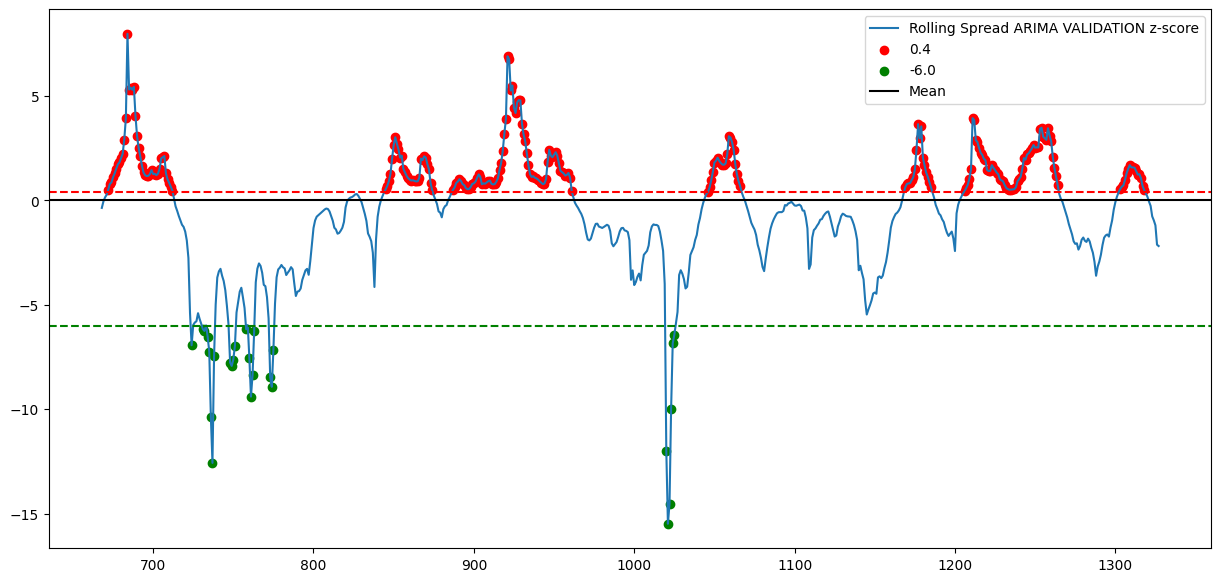

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 648.7438094403709, 1297.876636693668, 1950.1428660932716, 2590.326139260791, 3242.382820633689, 3894.8384344485785, 4555.0881791846505, 5220.141959297132, 5891.837376904728, 6561.549329553903, 7208.277067579415, 7848.1368302004585, 8486.768042497759, 9130.41588550374, 9796.304414160613, 10469.515802490014, 11148.159520097955, 11827.586358654307, 12507.847418248148, 13214.549617108518, 13923.357824081513, 14641.571964985795, 15387.933221231639, 16119.911088845147, 16854.734277571657, 17613.15701899607, 18377.991047887906, 19135.660176091595, 19900.21943560293, 20651.979084040016, 21384.0209734417, 22127.832883844327, 22893.528612770056, 23646.780219357697, 24

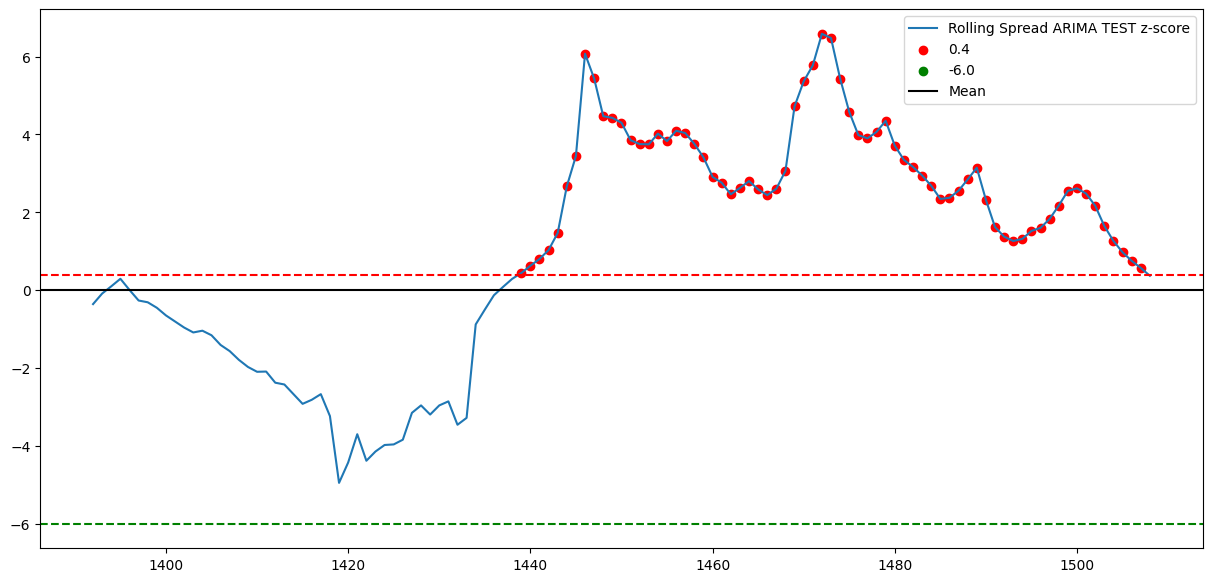

Optimal Parameters {'buy_threshold': -6.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 65, 'window2': 11}
Money on validation data 115033.93623072508
Money on test data 50993.1179091745


In [51]:
money_val = trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_val)
buy_signal_plots(spread_ARIMA_val,S1_val,S2_val,window1,window2,sell_threshold,buy_threshold,label="ARIMA VALIDATION")

money_test = trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_test)
buy_signal_plots(spread_ARIMA_test,S1_test,S2_test,window1,window2,sell_threshold,buy_threshold,label="ARIMA TEST")


print("Optimal Parameters",byopt.optimize_results["best_params"])
print("Money on validation data",money_val[-1])
print("Money on test data",money_test[-1])

In [56]:
mean_semi_deviation = MeanSemiDeviation(chi=0.6)
byopt_msd =  gridsearchOpt(mean_semi_deviation)
params_msd = byopt_msd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_msd.optimize_results["best_params"])
window1_msd = byopt_msd.optimize_results["best_params"]["window1"]
window2_msd = byopt_msd.optimize_results["best_params"]["window2"]
sell_threshold_msd = byopt_msd.optimize_results["best_params"]["sell_threshold"]    
buy_threshold_msd = byopt_msd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_msd = byopt_msd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_msd.optimize_results["best_params"])

Total Parameters : 8640
Current Progress: 1/8640 : best_score : 0.0 
Current Progress: 101/8640 : best_score : 0.0 
Current Progress: 201/8640 : best_score : 0.0 
Current Progress: 301/8640 : best_score : 0.0 
Current Progress: 401/8640 : best_score : 0.0 
Current Progress: 501/8640 : best_score : 0.0 
Current Progress: 601/8640 : best_score : 0.0 
Current Progress: 701/8640 : best_score : 0.0 
Current Progress: 801/8640 : best_score : 0.0 
Current Progress: 901/8640 : best_score : 0.0 
Current Progress: 1001/8640 : best_score : 0.0 
Current Progress: 1101/8640 : best_score : 0.0 
Current Progress: 1201/8640 : best_score : 0.0 
Current Progress: 1301/8640 : best_score : 0.0 
Current Progress: 1401/8640 : best_score : 0.0 
Current Progress: 1501/8640 : best_score : 39.909995297948605 
Current Progress: 1601/8640 : best_score : 39.909995297948605 
Current Progress: 1701/8640 : best_score : 39.909995297948605 
Current Progress: 1801/8640 : best_score : 39.909995297948605 
Current Progress

In [69]:
# Do the same thing for TotalSemiDeviation
total_semi_deviation = MeanSemiDeviation(chi=0.9)
print(total_semi_deviation.chi)
byopt_tsd =  gridsearchOpt(total_semi_deviation)
params_tsd = byopt_tsd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_tsd.optimize_results["best_params"])
window1_tsd = byopt_tsd.optimize_results["best_params"]["window1"]
window2_tsd = byopt_tsd.optimize_results["best_params"]["window2"]
sell_threshold_tsd = byopt_tsd.optimize_results["best_params"]["sell_threshold"]
buy_threshold_tsd = byopt_tsd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_tsd = byopt_tsd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_tsd.optimize_results["best_params"])

0.9
Total Parameters : 8640
Current Progress: 1/8640 : best_score : 0.0 
Current Progress: 101/8640 : best_score : 0.0 
Current Progress: 201/8640 : best_score : 0.0 
Current Progress: 301/8640 : best_score : 0.0 
Current Progress: 401/8640 : best_score : 0.0 
Current Progress: 501/8640 : best_score : 0.0 
Current Progress: 601/8640 : best_score : 0.0 
Current Progress: 701/8640 : best_score : 0.0 
Current Progress: 801/8640 : best_score : 0.0 
Current Progress: 901/8640 : best_score : 0.0 
Current Progress: 1001/8640 : best_score : 0.0 
Current Progress: 1101/8640 : best_score : 0.0 
Current Progress: 1201/8640 : best_score : 0.0 
Current Progress: 1301/8640 : best_score : 0.0 
Current Progress: 1401/8640 : best_score : 0.0 
Current Progress: 1501/8640 : best_score : 9.716688628899448 
Current Progress: 1601/8640 : best_score : 9.716688628899448 
Current Progress: 1701/8640 : best_score : 9.716688628899448 
Current Progress: 1801/8640 : best_score : 9.716688628899448 
Current Progress

In [ ]:
{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.6736842105263159, 'window1': 23, 'window2': 12}

In [57]:
rd_window_1 = 65
rd_window_2 = 10
rd_sell_threshold = 1
rd_buy_threshold = -2
rd_clear_threshold = 0

# Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 65, 'window2': 12}
# Money on validation data 75911.82971778436
# Money on test data 38066.41664118262

In [ ]:
money_val_rd = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_val_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_val_msd_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)
money_val_tsd_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_tsd, window2_tsd,sell_threshold_tsd,buy_threshold_tsd,clear_threshold_tsd)
# money_val_td_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_td, window2_td,sell_threshold_td,buy_threshold_td,clear_threshold_td)

In [232]:
# Calculate Exponational Utility

def utility(risk_aversion,money_arr):
    return -1*np.mean(np.exp(-risk_aversion *np.array(money_arr)))

print("Risk Aversion Utility rd",utility(0.009,money_val_rd))
print("Risk Aversion Utility opt",utility(0.009,money_val_opt))
print("Risk Aversion Utility exp",utility(0.009,money_val_exp_opt))
print("Risk Aversion Utility msd",utility(0.009,money_val_msd_opt))


Risk Aversion Utility rd -16463640.94400226
Risk Aversion Utility opt -0.17270497828627324
Risk Aversion Utility exp -0.07326585932717206
Risk Aversion Utility msd -0.09014591175162122


In [233]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.2142082488099,
 971.4702793156173,
 1457.5431114743621,
 1944.0979094710349,
 2441.4350206927966,
 2934.520921193781,
 3426.2913682095696,
 3908.349886639085,
 4396.765805969503,
 4894.377461957076,
 5400.247189109047,
 5901.980962793682,
 6404.382010950167,
 6901.958730401068,
 7408.142522117675,
 7917.922178572962,
 8424.882779433452,
 8930.381467631085,
 9433.691511715688,
 9938.385935991168,
 10440.659116302653,
 10937.191516930927,
 11430.816334428164,
 11921.109184799496,
 12411.868082743978,
 12907.141498837203,
 13407.038354249087,
 13908.523343871602,
 14400.292354404526,
 14882.151448716742,
 14882.15144871674

In [234]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.2142082488099,
 971.4702793156173,
 1457.5431114743621,
 1944.0979094710349,
 2441.4350206927966,
 2934.520921193781,
 3426.2913682095696,
 3908.349886639085,
 4396.765805969503,
 4894.377461957076,
 5400.247189109047,
 5901.980962793682,
 6404.382010950167,
 6901.958730401068,
 7408.142522117675,
 7917.922178572962,
 8424.882779433452,
 8930.381467631085,
 9433.691511715688,
 9938.385935991168,
 10440.659116302653,
 10937.191516930927,
 11430.816334428164,
 11921.109184799496,
 12411.868082743978,
 12907.141498837203,
 13407.038354249087,
 13908.523343871602,
 14400.292354404526,
 14882.151448716742,
 14882.15144871674

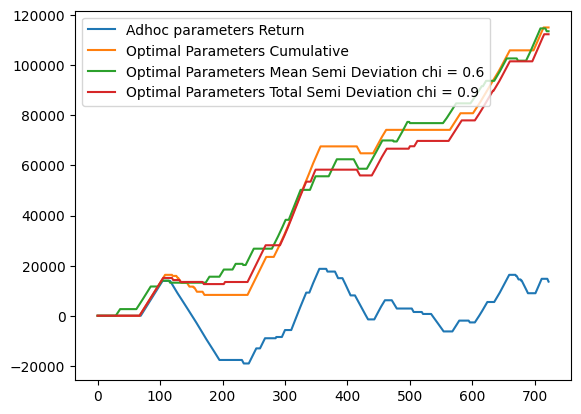

In [70]:
plt.plot(money_val_rd)
plt.plot(money_val_opt)
plt.plot(money_val_msd_opt)
plt.plot(money_val_tsd_opt)
# plt.plot(money_val_td_opt)
plt.legend(["Adhoc parameters Return","Optimal Parameters Cumulative","Optimal Parameters Mean Semi Deviation chi = 0.6","Optimal Parameters Total Semi Deviation chi = 0.9","Optimal Parameters Total Deviation"], loc="upper left")

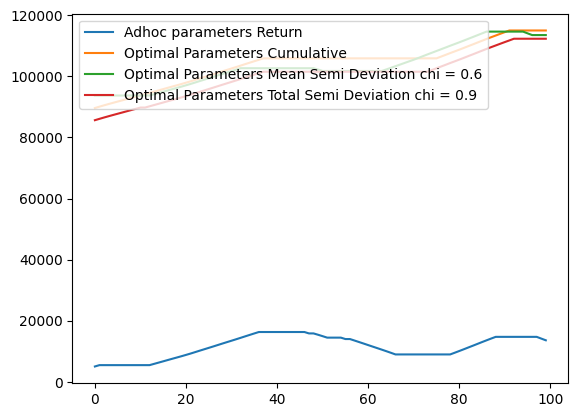

In [68]:
plt.plot(money_val_rd[-100:])
plt.plot(money_val_opt[-100:])
plt.plot(money_val_msd_opt[-100:])
plt.plot(money_val_tsd_opt[-100:])
# plt.plot(money_val_td_opt[-100:])
plt.legend(["Adhoc parameters Return","Optimal Parameters Cumulative","Optimal Parameters Mean Semi Deviation chi = 0.6","Optimal Parameters Total Semi Deviation chi = 0.9","Optimal Parameters Total Deviation"], loc="upper left")

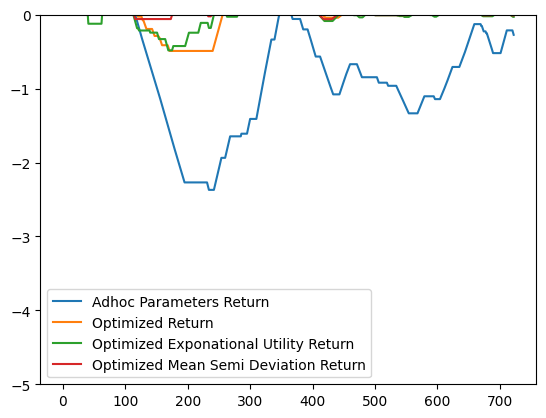

In [60]:
plt.plot(calculate_drawdown(money_val_rd),label="Adhoc Parameters Return")
plt.plot(calculate_drawdown(money_val_opt),label="Optimized Return")
plt.plot(calculate_drawdown(money_val_exp_opt),label="Optimized Exponational Utility Return")
plt.plot(calculate_drawdown(money_val_msd_opt),label="Optimized Mean Semi Deviation Return")
plt.ylim([-5,0])
plt.legend()


In [61]:
val_drawdown = np.min(calculate_drawdown(money_val_rd))
val_opt_drawdown = np.min(calculate_drawdown(money_val_opt))
val_exp_drawdown = np.min(calculate_drawdown(money_val_exp_opt))

print("Val drawdown",val_drawdown)
print("Val optimized drawdown",val_opt_drawdown)
print("Val optimized exponational drawdown",val_exp_drawdown)
print("Val optimized mean semi deviation drawdown",np.min(calculate_drawdown(money_val_msd_opt)))
print("Val optimized total semi deviation drawdown",np.min(calculate_drawdown(money_val_tsd_opt)))


Val drawdown -2.3700107874865157
Val optimized drawdown -0.4906539192253478
Val optimized exponational drawdown -0.48257903616225334
Val optimized mean semi deviation drawdown -0.06047599218424677
Val optimized total semi deviation drawdown -0.16259030953801284


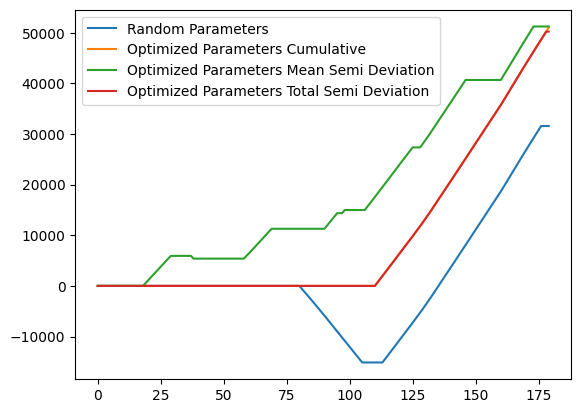

In [73]:
money_test_rd = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_test_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_test_msd_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)
money_test_tsd_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_tsd, window2_tsd,sell_threshold_tsd,buy_threshold_tsd,clear_threshold_tsd)
# money_test_td_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_td, window2_td,sell_threshold_td,buy_threshold_td,clear_threshold_td)

plt.plot(money_test_rd)
plt.plot(money_test_opt)
plt.plot(money_test_msd_opt)
plt.plot(money_test_tsd_opt)
# plt.plot(money_test_td_opt)
plt.legend(["Random Parameters","Optimized Parameters Cumulative","Optimized Parameters Mean Semi Deviation","Optimized Parameters Total Semi Deviation"])

In [63]:
print("Money gain using random parameters",money_test_rd[-1])
print("Money gain using optimized parameters",money_test_opt[-1])
print("Money gain using optimized parameters exponational",money_test_exp_opt[-1])

print("Performance gain over benchmark Cumilative  ",(money_test_opt[-1]- money_test_rd[-1])/money_test_rd[-1])

print("Performance gain over benchmark exponational",(money_test_exp_opt[-1]- money_test_rd[-1])/money_test_rd[-1])


Money gain using random parameters 31575.53799707725
Money gain using optimized parameters 50993.1179091745
Money gain using optimized parameters exponational 50572.79710520337
Performance gain over benchmark Cumilative   0.6149564233519826
Performance gain over benchmark exponational 0.6016448273940599


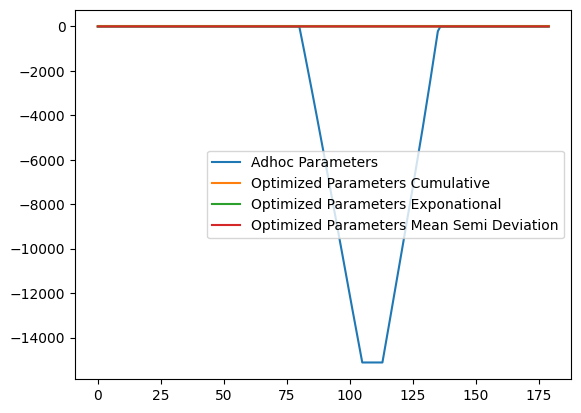

In [64]:
plt.plot(calculate_drawdown(money_test_rd),label="Adhoc Parameters")
plt.plot(calculate_drawdown(money_test_opt),label="Optimized Parameters Cumulative")
plt.plot(calculate_drawdown(money_test_exp_opt),label="Optimized Parameters Exponational")
plt.plot(calculate_drawdown(money_test_msd_opt),label="Optimized Parameters Mean Semi Deviation")
# plt.ylim(-1,0)
plt.legend()

In [65]:
val_test_rd = calculate_drawdown(money_test_rd)
val_test_opt = calculate_drawdown(money_test_opt)
val_test_exp_op = calculate_drawdown(money_test_exp_opt)
val_test_msd_op = calculate_drawdown(money_test_msd_opt)

print("Test drawdown",np.min(val_test_rd))
print("Test optimized drawdown",np.min(val_test_opt))
print("Test optimized drawdown",np.min(val_test_exp_op))
print("Test optimized mean semi deviation drawdown",np.min(val_test_msd_op))

#Reduction in drawdown
print("Reduction in drawdown Cumilative  ",(np.min(val_test_rd)-np.min(val_test_opt))/np.min(val_test_rd))
print("Reduction in drawdown Exponational  ",(np.min(val_test_rd)-np.min(val_test_exp_op))/np.min(val_test_rd))
print("Reduction in drawdown Mean Semi Deviation  ",(np.min(val_test_rd)-np.min(val_test_msd_op))/np.min(val_test_rd))





Test drawdown -15123.0
Test optimized drawdown 0.0
Test optimized drawdown -0.12730670404111188
Test optimized mean semi deviation drawdown -0.09189006912830888
Reduction in drawdown Cumilative   1.0
Reduction in drawdown Exponational   0.9999915819146967
Reduction in drawdown Mean Semi Deviation   0.9999939238200669


In [ ]:
# Calculate sharpe from wealth
def sharpe_ratio(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    return (np.mean(daily_returns) / np.std(daily_returns))*np.sqrt(252)

# Calculate sharpe ratio on test data
sharpe_rd = sharpe_ratio(money_test_rd)
sharpe_opt = sharpe_ratio(money_test_opt)
sharpe_exp = sharpe_ratio(money_test_exp_opt)
sharpe_msd = sharpe_ratio(money_test_msd_opt)

print("Sharpe Ratio Random Parameters",sharpe_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_exp)
print("Sharpe Ratio Optimized Parameters Mean Semi Deviation",sharpe_msd)

In [ ]:
len(money_val_rd)

In [ ]:
# Calculate average drawdowns
def average_drawdown(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    drawdowns = (np.maximum.accumulate(daily_returns) - daily_returns)
    return np.mean(drawdowns)

In [ ]:
# calculate returns from portfolio wealth using numpy 
np.diff(money_val_rd)/money_val_rd[:-1]

In [ ]:
# Calculate sharpe on validation data
sharpe_val_rd = sharpe_ratio(money_val_rd)
sharpe_val_opt = sharpe_ratio(money_val_opt)
sharpe_val_exp = sharpe_ratio(money_val_exp_opt)
print("Sharpe Ratio Random Parameters",sharpe_val_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_val_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_val_exp)

In [ ]:
returns = pd.Series(money_test_exp_opt).pct_change()[1:]
portfolio_returns = pd.Series(money_test_exp_opt).sum(axis=1)
# cumulative_returns = (1 + portfolio_returns).cumprod() * 
cumilative_returns = money_test_exp_opt

# roi = (cumulative_returns[-1] / self.portfolio_value - 1) * 100
sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
drawdown = (cumilative_returns.cummax() - cumilative_returns) / cumilative_returns.cummax()
max_drawdown = drawdown.max() * 100

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
result = adfuller(pm.data['Spread_Close'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

In [ ]:
plot_acf(pm.data['Spread_Close'],lags=50)
plt.show()

In [ ]:
plot_pacf(pm.data['Spread_Close'],lags=50)
plt.show()

In [ ]:
result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

In [ ]:
plot_acf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [ ]:
plot_pacf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [ ]:

result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])